# AG-HYPOPT · Trial 01

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Situation at campaign start (trial_01). The trials.json registry is empty: no previous trials
exist, so there is no incumbent objective and no within-campaign data yet. exp7 freezes both the
learning-rate schedule (exp5 winner: lr_mu 0.1669, mu_anneal 0.3455, lr_gamma 0.4716, gamma_anneal
0.4723) and the score design (exp6 winner: sigma_weight 0.865, gamma_rel_cap 0.107), and searches
only the KDE bandwidth: the rule family (target | sim | power) plus the coefficients h_f_scale and
h_s_scale, now extended to [1, 12]. Inherited evidence is exp6: its best was objective 0.0803 with
the target rule at h_f=4.0, h_s=3.675; that optimum sat pinned at exp6's h_f upper bound (17/30
trials) with corr(obj, h_f_scale) = -0.948 and corr(obj, h_s_scale) = -0.809, i.e. the kernel
wanted to be flatter than the space allowed. The defaults (target, 4.0, 3.675) reproduce the exp6
winner exactly (0.080328). Benchmark: 8-exp subset; campaign cap 30 trials.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_01'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (1/5 trials)
ID |     ei | params
 1 |      - | {"bandwidth_rule": "sim", "h_f_scale": 11.455100659585288, "h_s_scale": 2.585755739915971}
 2 |      - | {"bandwidth_rule": "sim", "h_f_scale": 11.435143918509683, "h_s_scale": 4.43014597211534}
 3 |      - | {"bandwidth_rule": "power", "h_f_scale": 10.10472853202486, "h_s_scale": 5.501190500060774}
 4 |      - | {"bandwidth_rule": "sim", "h_f_scale": 7.045530564403655, "h_s_scale": 1.303150245673752}
 5 |      - | {"bandwidth_rule": "power", "h_f_scale": 6.91957644541206, "h_s_scale": 4.627048881490014}
 6 |      - | {"bandwidth_rule": "power", "h_f_scale": 9.672715737712448, "h_s_scale": 4.335143122208095}
 7 |      - | {"bandwidth_rule": "target", "h_f_scale": 2.4744586697188122, "h_s_scale": 5.434242850918421}
 8 |      - | {"bandwidth_rule": "sim", "h_f_scale": 3.238007647437646, "h_s_scale": 3.8854467448603445}
 9 |      - | {"bandwidth_rule": "target", "h_f_scale": 4.084496337846439, "h_s_scale": 6.337100718747986}

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

The registry is empty, so there is no within-campaign evidence to condition on; the only prior is
exp6. That prior is unambiguous: the bandwidth is the dominant lever, both coefficients correlate
negatively with the objective, and the winning rule was `target` with h_f pinned at its old upper
bound of 4.0. The direct, lowest-risk follow-up is therefore to keep the winning rule and push the
coefficients up into the newly opened [4, 12] range.

The ten proposals (phase: uniform, no EI yet) contain three `target` candidates: #7 (h_f 3.18,
h_s 2.87) which is below exp6's winning point and mostly re-tests known ground; #3 (h_f 5.35,
h_s 7.65); and #9 (h_f 11.35, h_s 10.29) which is nearly at the cap on both axes. The remaining
candidates are `power` (#1, #4, #5, #6) and `sim` (#2, #8, #10), i.e. brand-new rules with no
supporting evidence yet.

Candidate #3 extends the winning `target` rule into the newly opened range at moderate-high
coefficients. It directly tests the exp6 hypothesis ("flatter is better, but the space ran out") without
jumping to a nearly flat kernel, where the responsibilities go uniform and the REINFORCE mu channel
dies - a known failure mode. It is the most sensible single first trial: it builds a likely-good
incumbent early while probing the turnover region, and it leaves the near-cap and new-rule cells
for later, informed trials.

I choose candidate 3 (target, h_f_scale 5.349, h_s_scale 7.652).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 5.349150430330462, 'h_s_scale': 7.6521429754810875}
Running  1nW Trans05 ... 

μ 9.39 -> 5.48 | γ 8.5 -> 6.19 | NLL 0.10


Running  1nW Trans20 ... 

μ 17.32 -> 22.51 | γ 8.5 -> 4.96 | NLL 0.29


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 63.60 | γ 14.1 -> 13.64 | NLL 0.39


Running 3nW Trans100 ... 

μ 175.71 -> 95.88 | γ 14.1 -> 13.58 | NLL 0.37



Total: 7.2 min


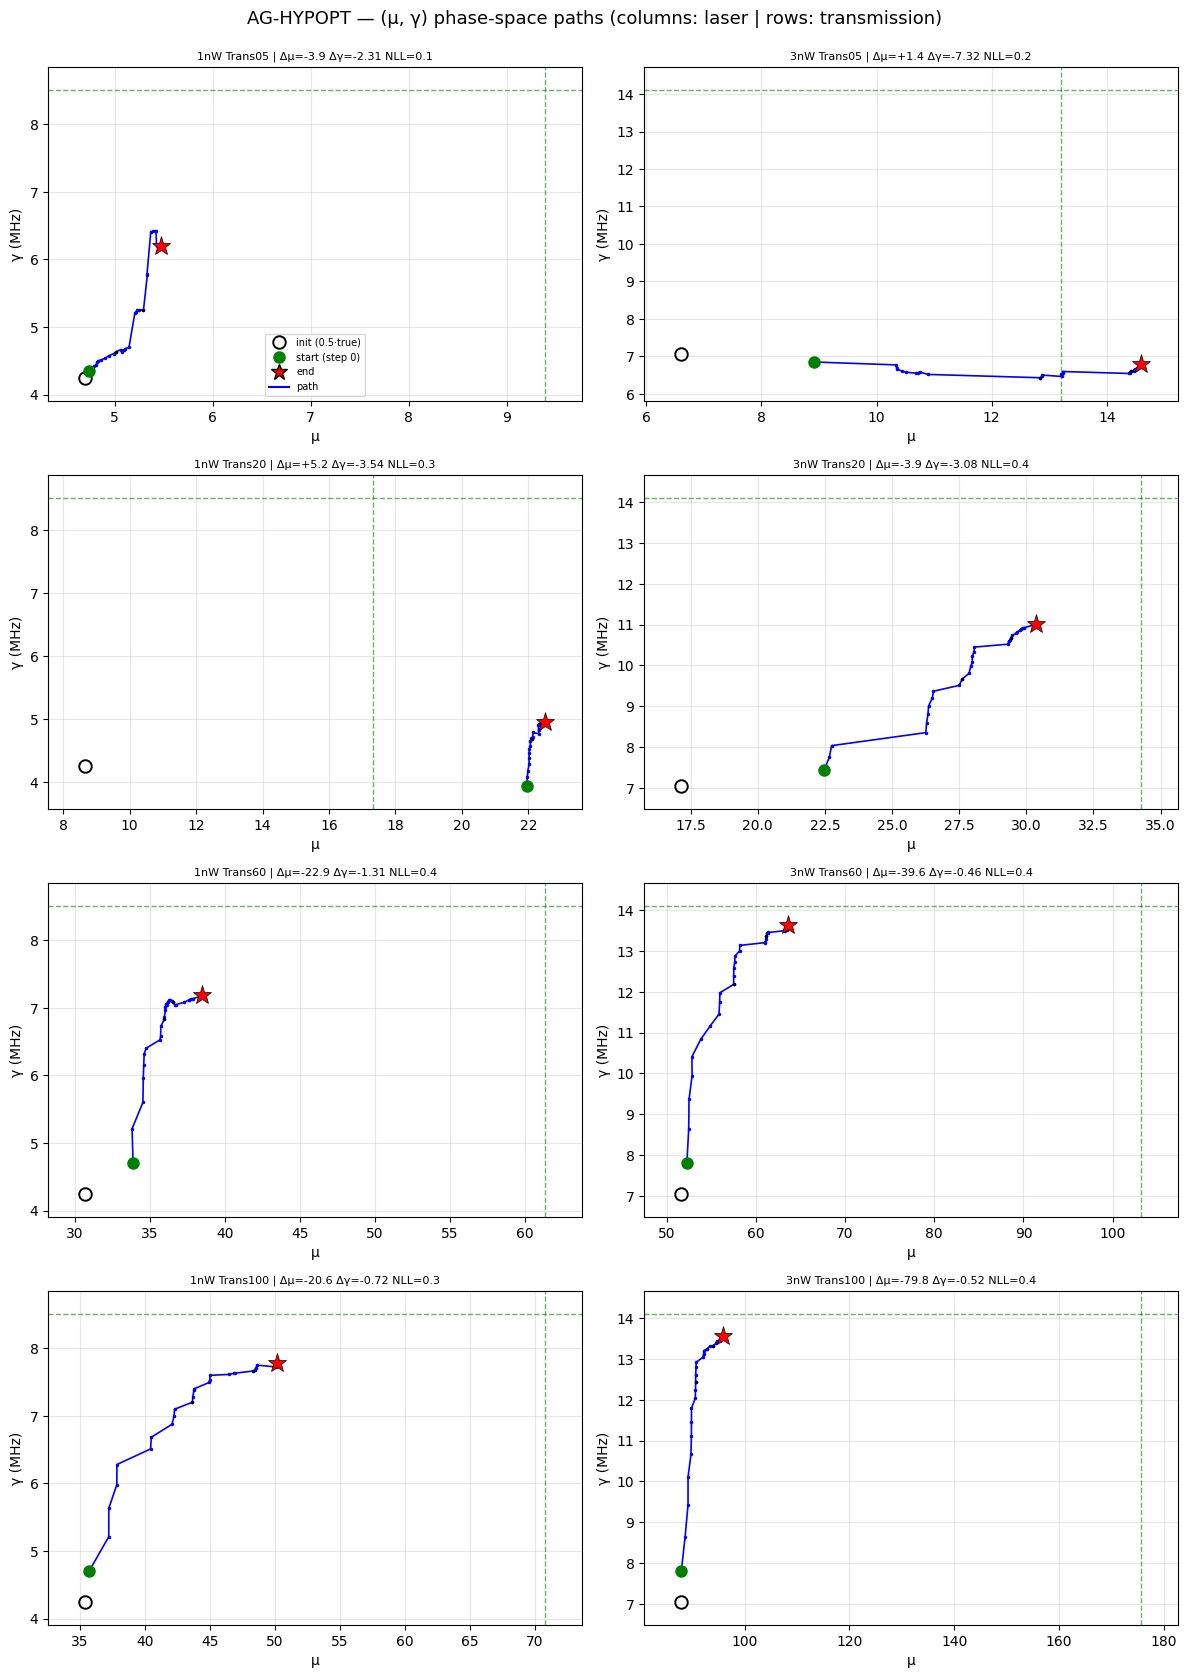

trial finished in 7.2 min
objective = 0.0837 ± 0.0211
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.48   -41.7 |     8.50    6.19   -27.1
1nW Trans20       17.32   22.51   +30.0 |     8.50    4.96   -41.7
1nW Trans60       61.37   38.48   -37.3 |     8.50    7.19   -15.4
1nW Trans100       70.82   50.20   -29.1 |     8.50    7.78    -8.4
3nW Trans05       13.20   14.60   +10.6 |    14.10    6.78   -51.9
3nW Trans20       34.28   30.36   -11.4 |    14.10   11.02   -21.8
3nW Trans60      103.20   63.60   -38.4 |    14.10   13.64    -3.2
3nW Trans100      175.71   95.88   -45.4 |    14.10   13.58    -3.7

weighted objective (T-graded, cap=1.0) = 0.0837 | diverged cells: 0
μ: RMSE 33.446 (rel 32.9%, bias -20.523) | γ: RMSE 3.232 (rel 27.3%, bias -2.406)


ValueError: Unknown format code 'g' for object of type 'str'

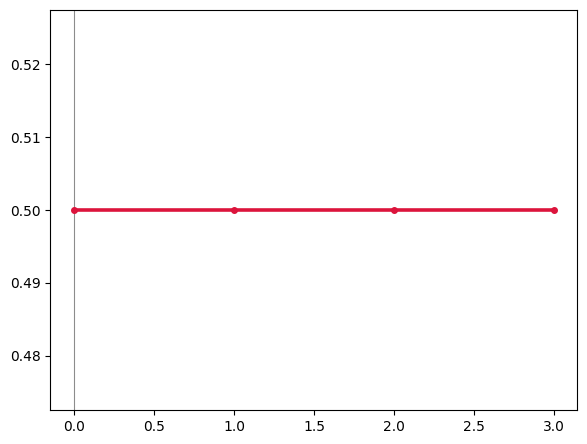

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0837 ± 0.0211, gamma finite on all 8 benchmark cells, diverged cells: 0. Config:
bandwidth_rule = target, h_f_scale = 5.349, h_s_scale = 7.652 - i.e. the winning exp6 rule pushed to a
higher bandwidth on both channels.

Per-cell behaviour: mu rel-RMSE 32.9 % (bias -20.5), gamma rel-RMSE 27.3 % (bias -2.41). mu is
underestimated in 6 of 8 cells (the two exceptions, 1nW Trans20 +30.0 % and 3nW Trans05 +10.6 %,
are the low-count cells); gamma is underestimated in all 8 cells, most severely in the low-count
cells (1nW Trans05 -27.1 %, 1nW Trans20 -41.7 %, 3nW Trans05 -51.9 %) and only mildly at high T
(3nW Trans60/100 -3.2 %/-3.7 %). Low-transmission cells drive the residual.

Comparison with exp6: this config is a direct extension of exp6's winner (target, h_f 4.0, h_s
3.675 -> 0.0803) into the newly opened range. Raising the coefficients to 5.35/7.65 gives 0.0837,
i.e. it clears the campaign success bar (~0.086) but does not beat exp6's headline 0.0803. Within
the reported sampling uncertainty (±0.0211) this is close to exp6, but it is the first hint that the
target rule's optimum is not far above exp6's h_f = 4.0 - consistent with a turnover rather than
"flatter is always better". No previous within-campaign trials exist to compare against; this is
trial 1 of 30.

Execution note: the trial's own numbers were produced cleanly (objective computed, 7.2 min, no
divergence). The trailing `plot_parallel` diagnostic call raised `ValueError: Unknown format code
'g' for object of type 'str'` (ag_hypopt.py:1224, formatting the string `bandwidth_rule` axis label
with `.3g`), so the parallel-coordinates figure did not render. This is a plotting-helper bug only -
it does not affect the objective, which was already computed and printed - so the trial stands, no
rerun needed.

**Summary:** Trial 1 (target rule, h_f 5.349, h_s 7.652) scores objective 0.0837 ± 0.0211 with gamma finite on all 8 cells and no divergence, clearing the success bar but sitting just above exp6's 0.0803.
**Key insight:** Pushing the winning target rule from exp6's h_f 4.0 up to 5.35 (and h_s 3.675 -> 7.65) does not improve the objective (0.0803 -> 0.0837), the first sign of a turnover above exp6's optimum.

Notes for Anuar (optional, not acted on): the only code defect seen so far is the `plot_parallel`
label-formatting bug (`.3g` applied to the string-valued `bandwidth_rule` axis), which only affects
the campaign's diagnostic figure. Worth a one-line fix when convenient, but it is structural/tooling
code and outside this campaign's scope, so I am leaving it untouched.

**Summary:** [One-line summary of this trial]
**Key insight:** [One sentence]

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar (optional)]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 1 (target rule, h_f 5.349, h_s 7.652) scores objective 0.0837 ± 0.0211 with gamma finite on all 8 cells and no divergence, clearing the success bar but sitting just above exp6's 0.0803."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Pushing the winning target rule from exp6's h_f 4.0 up to 5.35 (and h_s 3.675 -> 7.65) does not improve the objective (0.0803 -> 0.0837), the first sign of a turnover above exp6's optimum."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_XXX | current best: trial_XXX


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_02.ipynb. Open it and follow its cells from the top.
